In this notebook we train two models (model_start and model_end) and then a third model_theta.

In [1]:
from models import MyNet, Lenet5, tiny, MyNet_small, CIFAR10ConvNet
import torch
from scheduler import make_scheduler
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
from train import train
from curve_model import Curve
import os
import matplotlib.pyplot as plt
import torchmetrics
from curve_plots import plot_Curve_losslandscape, affine_subspace, bezier_plot
import pandas as pd

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

root = ".."
datafolder = f"{root}/data"
base_directory = f"{root}/experiments/results_notebook"

In [2]:
MODEL = CIFAR10ConvNet
model_kargs = {"dropout": 0.5}
loss_fn = torch.nn.CrossEntropyLoss(weight=None, size_average=None, ignore_index=-100, reduce=None, reduction='mean', label_smoothing=0.0)
batch_size = 256

dataset = "CIFAR10"
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.CIFAR10(root=f'{datafolder}/train', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root=f'{datafolder}/test', train=False, download=True, transform=transform)
subset_test = Subset(test_dataset, indices=range(len(test_dataset) // 1))
subset_train = Subset(train_dataset, indices=range(len(train_dataset) // 1))
test_loader = DataLoader(subset_test, batch_size=batch_size)
train_loader = DataLoader(subset_train, batch_size=batch_size)


/Users/simondanieleiriksson/Documents/GitHub/mode-connectivity/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


epoch = 1 	train loss: 2.11144, test loss: 1.81383, test accuracy: 35.22, lr: 4.800000e-04
epoch = 2 	train loss: 1.72345, test loss: 1.60181, test accuracy: 42.61, lr: 8.600000e-04
epoch = 3 	train loss: 1.56216, test loss: 1.45245, test accuracy: 47.95, lr: 1.240000e-03
epoch = 4 	train loss: 1.47070, test loss: 1.39219, test accuracy: 49.59, lr: 1.620000e-03
epoch = 5 	train loss: 1.38298, test loss: 1.28774, test accuracy: 55.06, lr: 2.000000e-03
epoch = 6 	train loss: 1.31459, test loss: 1.18502, test accuracy: 57.23, lr: 2.000000e-03
epoch = 7 	train loss: 1.23870, test loss: 1.13604, test accuracy: 60.11, lr: 2.000000e-03
epoch = 8 	train loss: 1.17083, test loss: 1.04581, test accuracy: 63.02, lr: 2.000000e-03
epoch = 9 	train loss: 1.12865, test loss: 0.99704, test accuracy: 65.29, lr: 2.000000e-03
epoch = 10 	train loss: 1.09074, test loss: 0.98896, test accuracy: 65.15, lr: 2.000000e-03
epoch = 11 	train loss: 1.04610, test loss: 0.93581, test accuracy: 67.33, lr: 2.000000e-

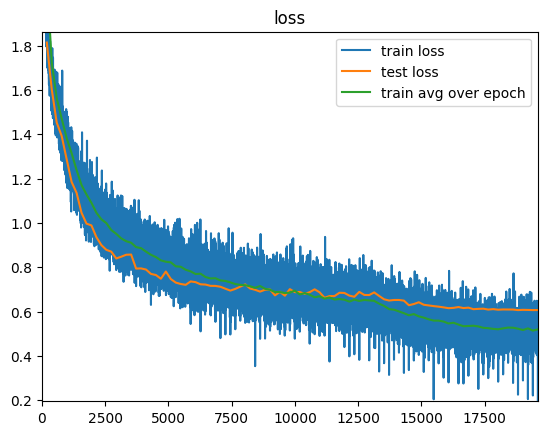

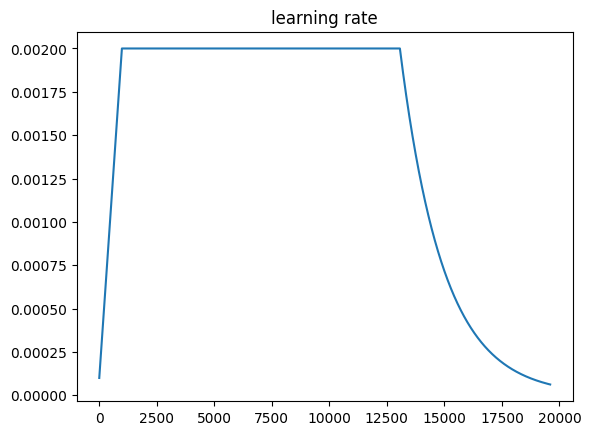

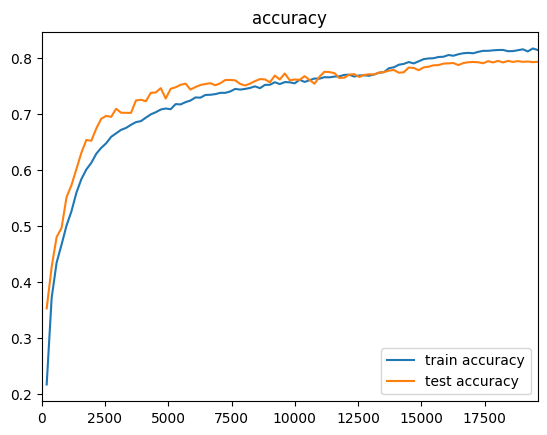

In [3]:
os.makedirs(f"{base_directory}/models", exist_ok=True)
os.makedirs(f"{base_directory}/figures", exist_ok=True)

retrain=True
if retrain:
    model_lr_start = torch.tensor(1e-4)
    model_lr_end = torch.tensor(2e-3)
    model_epochs = 100

    total_iter = model_epochs*train_loader.__len__()

    model_start = MODEL(**model_kargs).to(device)
    optimizer_start = torch.optim.Adam(params=model_start.parameters(), lr=model_lr_start.clone())
    scheduler_start = make_scheduler(optimizer_start, 
                                             train_num_steps=total_iter, 
                                             lr_start_warmup=model_lr_start.clone(), 
                                             lr=model_lr_end.clone(), 
                                             lr_warmup_steps=5*train_loader.__len__(), 
                                             lr_finetune_halftime=total_iter // (5*3), 
                                             lr_finetune_steps=total_iter // 3
            )
    model_start, all_train_losses, lrs, epoch_train_losses, test_losses, epoch_train_accuracy, plots = train(model_start, 
                                                train_loader=train_loader, 
                                                test_loader=test_loader, 
                                                optimizer=optimizer_start, 
                                                scheduler=scheduler_start, 
                                                epochs=model_epochs, loss_fn=loss_fn, device=device, 
                                                plot=True, plotpath=f"{base_directory}/start_model/figures",
                                                verbose=True
                                                )
    torch.save(model_start, f"{base_directory}/models/model_start_{MODEL.__name__}_{dataset}.pth")
    for k in plots.keys():
        display(plots[k][0])
else:
    model_start = torch.load(f"{base_directory}/models/model_start_{MODEL.__name__}_{dataset}.pth", map_location=torch.device(device), weights_only=False)

epoch = 1 	train loss: 2.06799, test loss: 1.73480, test accuracy: 39.09, lr: 4.800000e-04
epoch = 2 	train loss: 1.70401, test loss: 1.57522, test accuracy: 43.71, lr: 8.600000e-04
epoch = 3 	train loss: 1.57892, test loss: 1.46121, test accuracy: 47.03, lr: 1.240000e-03
epoch = 4 	train loss: 1.48588, test loss: 1.36779, test accuracy: 51.11, lr: 1.620000e-03
epoch = 5 	train loss: 1.40494, test loss: 1.26610, test accuracy: 54.29, lr: 2.000000e-03
epoch = 6 	train loss: 1.34268, test loss: 1.20814, test accuracy: 57.26, lr: 2.000000e-03
epoch = 7 	train loss: 1.27733, test loss: 1.16199, test accuracy: 58.70, lr: 2.000000e-03
epoch = 8 	train loss: 1.22458, test loss: 1.07692, test accuracy: 61.76, lr: 2.000000e-03
epoch = 9 	train loss: 1.17043, test loss: 1.05220, test accuracy: 62.48, lr: 2.000000e-03
epoch = 10 	train loss: 1.13252, test loss: 0.98893, test accuracy: 64.85, lr: 2.000000e-03
epoch = 11 	train loss: 1.09002, test loss: 0.95675, test accuracy: 66.10, lr: 2.000000e-

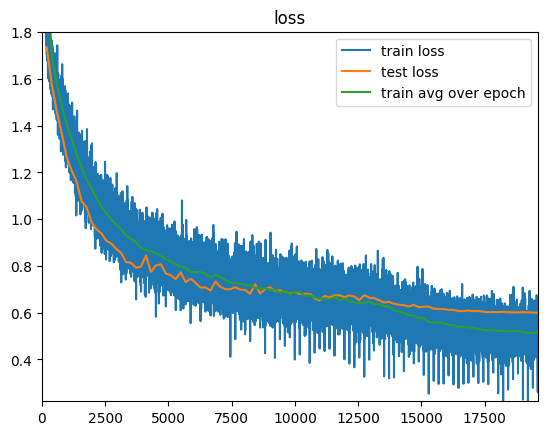

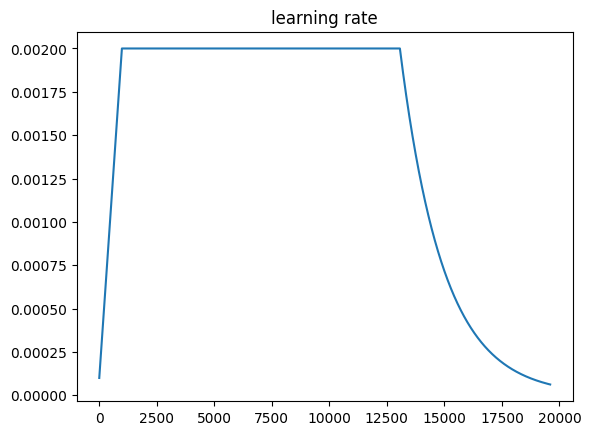

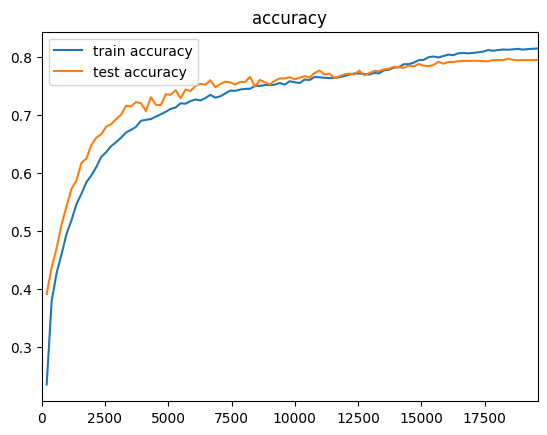

In [4]:
if retrain:
    model_lr_start = torch.tensor(1e-4)
    model_lr_end = torch.tensor(2e-3)
    model_epochs = 100

    total_iter = model_epochs*train_loader.__len__()

    model_end = MODEL(**model_kargs).to(device)
    optimizer_end = torch.optim.Adam(params=model_end.parameters(), lr=model_lr_start.clone())
    scheduler_end = make_scheduler(optimizer_end, 
                                             train_num_steps=total_iter, 
                                             lr_start_warmup=model_lr_start.clone(), 
                                             lr=model_lr_end.clone(), 
                                             lr_warmup_steps=5*train_loader.__len__(), 
                                             lr_finetune_halftime=total_iter // (5*3), 
                                             lr_finetune_steps=total_iter // 3
            )
    model_end, all_train_losses, lrs, epoch_train_losses, test_losses, epoch_train_accuracy, plots = train(model_end, 
                                                train_loader=train_loader, 
                                                test_loader=test_loader, 
                                                optimizer=optimizer_end, 
                                                scheduler=scheduler_end, 
                                                epochs=model_epochs, loss_fn=loss_fn, device=device, 
                                                plot=True, plotpath=f"{base_directory}/end_model/figures",
                                                verbose=True
                                                )
    torch.save(model_end, f"{base_directory}/models/model_end_{MODEL.__name__}_{dataset}.pth")
    for k in plots.keys():
        display(plots[k][0])
else:
    model_end = torch.load(f"{base_directory}/models/model_end_{MODEL.__name__}_{dataset}.pth", map_location=torch.device(device), weights_only=False)

In [5]:
def curve_fn(param_start, param_end, param_theta, t):
    return param_start * (1-t)**2 + param_end * t**2 + param_theta * 2*t*(1-t)

epoch = 1 	train loss: 1.28707, test loss: 1.14346, test accuracy: 62.55, lr: 2.008000e-02
epoch = 2 	train loss: 1.18482, test loss: 1.13444, test accuracy: 62.51, lr: 4.006000e-02
epoch = 3 	train loss: 1.06863, test loss: 1.15101, test accuracy: 61.43, lr: 6.004000e-02
epoch = 4 	train loss: 1.16393, test loss: 1.16185, test accuracy: 60.44, lr: 8.002000e-02
epoch = 5 	train loss: 0.99098, test loss: 0.94228, test accuracy: 68.00, lr: 1.000000e-01
epoch = 6 	train loss: 1.05875, test loss: 0.92329, test accuracy: 68.34, lr: 1.000000e-01
epoch = 7 	train loss: 0.92417, test loss: 0.97154, test accuracy: 66.71, lr: 1.000000e-01
epoch = 8 	train loss: 0.88943, test loss: 0.82528, test accuracy: 71.55, lr: 1.000000e-01
epoch = 9 	train loss: 0.79565, test loss: 0.86906, test accuracy: 69.90, lr: 1.000000e-01
epoch = 10 	train loss: 0.83716, test loss: 0.79144, test accuracy: 72.69, lr: 1.000000e-01
epoch = 11 	train loss: 0.85745, test loss: 0.90987, test accuracy: 68.62, lr: 1.000000e-

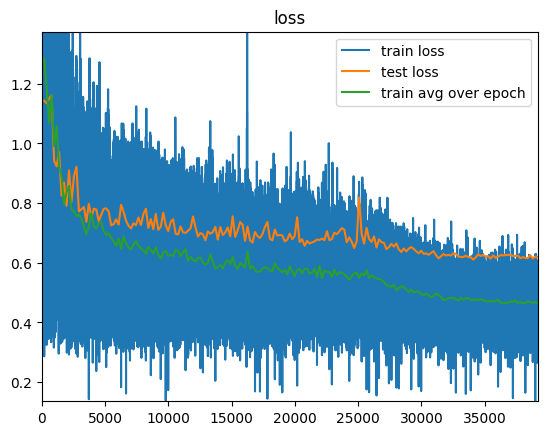

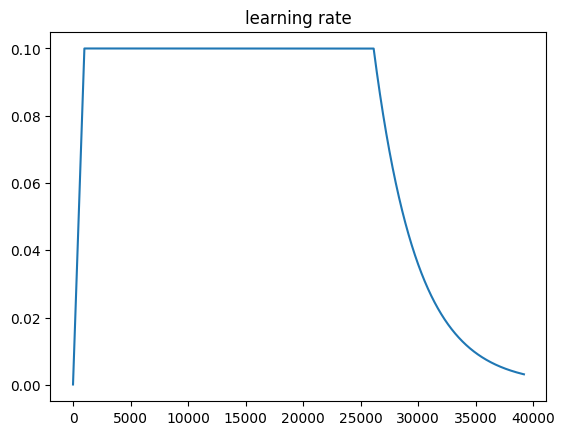

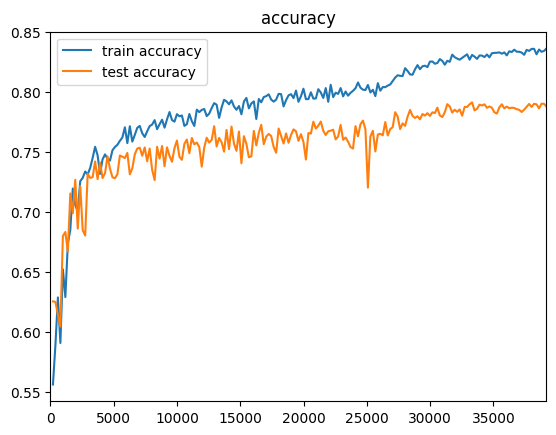

In [6]:
retrain_curve = True
curve_epochs= 200
curve_lr_start = torch.tensor(1e-4)
curve_lr_end = torch.tensor(1e-1)
curve_optimizer = "SGD"
total_iter = curve_epochs*train_loader.__len__()


if retrain_curve:
    total_iter = curve_epochs*train_loader.__len__()
    curve = Curve(model_start=model_start, model_end=model_end, curve_fn=curve_fn, device=device)
    gamma = ((curve_lr_end.log()-curve_lr_start.log())/(curve_epochs*train_loader.__len__())).exp()

    optimizer = torch.optim.SGD(params=curve.model_theta.parameters(), lr=curve_lr_start, momentum=0.9)

    scheduler = make_scheduler(optimizer, 
                                            train_num_steps=total_iter, 
                                            lr_start_warmup=curve_lr_start.clone(), 
                                            lr=curve_lr_end.clone(), 
                                            lr_warmup_steps=5*train_loader.__len__(), 
                                            lr_finetune_halftime=total_iter // (5*3), 
                                            lr_finetune_steps=total_iter // 3
        )
            

    curve, all_train_losses, lrs, epoch_train_losses, test_losses, epoch_train_accuracy, plots = train(curve, 
                                                                        train_loader=train_loader, 
                                                                        test_loader=test_loader, 
                                                                        optimizer=optimizer, 
                                                                        scheduler=scheduler, 
                                                                        epochs=curve_epochs,
                                                                        loss_fn=loss_fn, 
                                                                        device=device, 
                                                                        plot=True, 
                                                                        plotpath=f"{base_directory}/curve_model/figures", 
                                                                        #plotname=f"curvefitting_{MODEL.__name__}_{dataset}", 
                                                                        modeltype="curve", 
                                                                        verbose=True)
    torch.save(curve.model_theta, f"{base_directory}/models/curve.model_theta_{MODEL.__name__}_{dataset}.pth")
    for k in plots.keys():
        display(plots[k][0])
else:
    curve = Curve(model_start=model_start, model_end=model_end, curve_fn=curve_fn, device=device)
    curve.model_theta = torch.load(f"{base_directory}/models/curve.model_theta_{MODEL.__name__}_{dataset}.pth", map_location=torch.device(device), weights_only=False)
    

In [7]:
metrics_dict = {
    "Cross Entropy": lambda pred_probs, target: torch.nn.CrossEntropyLoss(weight=None, size_average=None, ignore_index=-100, reduce=None, reduction='mean', label_smoothing=0.0)(pred_probs.log(), target),
    "Expected Calibration Error": torchmetrics.classification.MulticlassCalibrationError(num_classes=10, n_bins=25).to(device),
    "Accuracy": lambda pred_probs, target: torchmetrics.functional.classification.accuracy(preds=pred_probs, target=target, task="multiclass", num_classes=10).to(device),
    "AUROC": lambda pred_probs, target: torchmetrics.functional.classification.auroc(preds=pred_probs, target=target, task="multiclass", num_classes=10).to(device)
}



begin loss landscape plot
begin calculation of mesh for loss landscape plot
finished loss landscape plotest_loss = 50.560124444580076



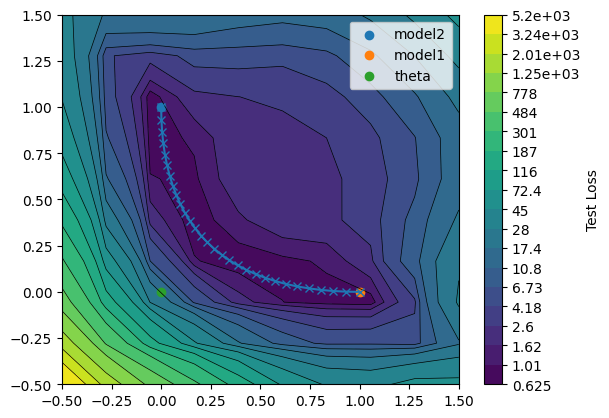

In [8]:
fig, ax = plot_Curve_losslandscape(curve, device, f"{base_directory}/figures", test_loader, N_points=10, loss_fn=loss_fn, recalc_mesh=True, N_bezierpoints=30)
fig.savefig(f"{base_directory}/figures/loss_landscape.png")
plt.show(fig)


begin evaluation of curve
N_obs = 10000
N_classes = 10
Cross Entropy start model: 0.6072253584861755
Cross Entropy end mode: 0.5998607277870178
Cross Entropy ensemble: 0.5447495579719543
Expected Calibration Error start model: 0.021371694281697273
Expected Calibration Error end mode: 0.02381555363535881
Expected Calibration Error ensemble: 0.04203708469867706
Accuracy start model: 0.7924000024795532
Accuracy end mode: 0.795199990272522
Accuracy ensemble: 0.8130000233650208
AUROC start model: 0.9761989712715149
AUROC end mode: 0.9769191741943359
AUROC ensemble: 0.9808539152145386
finished evaluation of curve



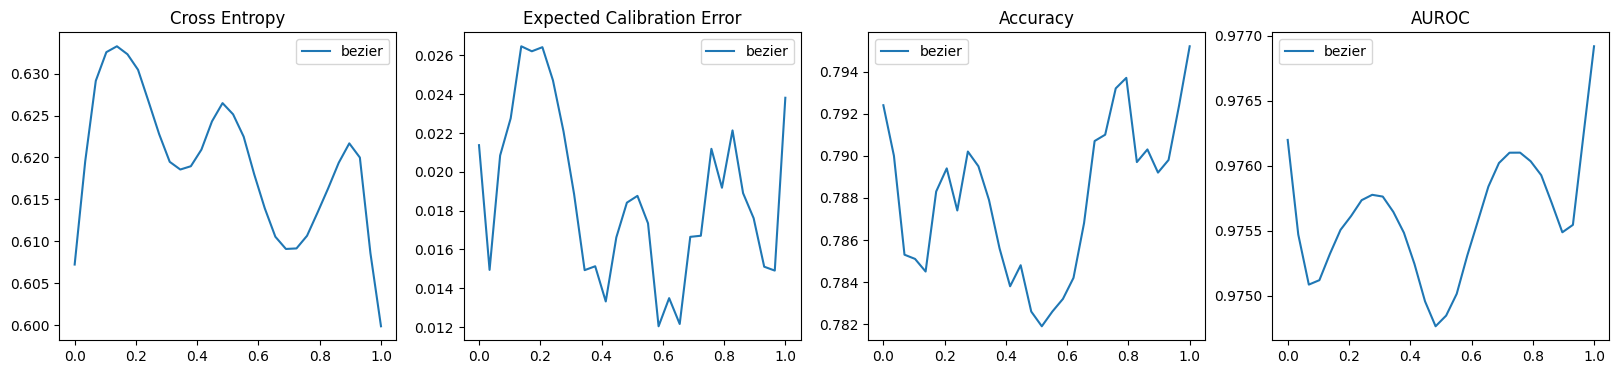

In [9]:
fig, axs, eval_results = bezier_plot(curve, device, test_loader=test_loader, 
                                     plottype="linear", 
                    N_bezierpoints = 30,
                    plot_linear=False, metrics_dict=metrics_dict)
fig.savefig(f"{base_directory}/figures/metric_along_curve.png")
plt.show(fig)

In [16]:
print(eval_results["curve_ensemble_score_dict"]["Ensemble"].keys())

dict_keys(['Cross Entropy', 'Expected Calibration Error', 'Accuracy', 'AUROC'])


In [23]:
pd.DataFrame(eval_results["curve_ensemble_score_dict"]).T.reset_index().rename(columns={"index": "Model"}).to_markdown(index=False)

'| Model       |   Cross Entropy |   Expected Calibration Error |   Accuracy |    AUROC |\n|:------------|----------------:|-----------------------------:|-----------:|---------:|\n| Start model |        0.607225 |                    0.0213717 |     0.7924 | 0.976199 |\n| End model   |        0.599861 |                    0.0238156 |     0.7952 | 0.976919 |\n| Ensemble    |        0.54475  |                    0.0420371 |     0.813  | 0.980854 |'